# Image Processing with OpenCV - Discovery Challenge

**Estimated Time:** 45 minutes  
**Course:** AI-2 Artificial Intelligence Foundations  
**Activity:** 14

Learn essential image processing techniques using OpenCV! This activity covers image resizing, color space conversions, edge detection, and blurring - fundamental skills for any computer vision project.

---

## 🎯 Learning Objectives

By the end of this activity, you will be able to:
- **Resize images** using cv2.resize() with different interpolation methods
- **Convert color spaces** (BGR to grayscale, HSV, RGB)
- **Apply edge detection** using Canny algorithm
- **Blur images** using Gaussian blur
- Understand when and why to use each technique

## 📍 Where to run what

This .ipynb is the **canonical edit surface** — work the TODOs in the code cells below; the lesson cells (text + working examples) are read-only context.

This notebook is **Colab-first**. Most code cells import `cv2_imshow` from `google.colab.patches`, which only exists inside Google Colab.

| Section | Cells | Runtime | Why |
|---|---|---|---|
| Setup: Verify Sample Images | 3 | **Colab OR local Jupyter** | Pure file I/O — no Colab dependency. |
| Working Examples 1–4 (load / resize / colorspace / edge+blur) | 5, 7, 9, 11 | **Colab ONLY** | Each cell does `from google.colab.patches import cv2_imshow`. In VS Code / local Jupyter you'll get `ModuleNotFoundError: No module named 'google'`. |
| TODO 1 (resize + convert) | 13 | **Colab ONLY** | Same `cv2_imshow` import. |
| TODO 2 (edge detection + blur) | 15 | **Colab ONLY** | Same `cv2_imshow` import. |
| Bonus: upload + process your own image | 18, 19 | **Colab ONLY** | Uses `from google.colab import files` (browser file picker). |

**If you're running locally:** open this notebook in [Google Colab](https://colab.research.google.com/) — that's the path of least friction. (For an offline alternative, you'd swap `cv2_imshow(img)` for `import matplotlib.pyplot as plt; plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); plt.show()` and remove the `google.colab` import everywhere — but the canonical edit target stays the `.ipynb` cells in this template.)

**TODOs you'll edit:** Cells 13 and 15 in this `.ipynb`. Run the Working Examples first to see the pattern, then write your code in the empty `# Your code here:` blocks.

---

## 📦 Setup: Verify Sample Images

The sample images are already included in this template folder. Let's verify they exist:

In [1]:
# =============================================================================
# 📦 Setup: Verify Sample Images - Works Locally, Browser Colab, AND VS Code + Colab!
# =============================================================================
import os
import urllib.request

# GitHub URLs for sample files
FILES = {
    'cats.jpg': 'https://raw.githubusercontent.com/KCW89/telebort-public-datasets/main/AI-2/images/cats.jpg',
    'outing_large.jpg': 'https://raw.githubusercontent.com/KCW89/telebort-public-datasets/main/AI-2/images/outing_large.jpg'
}

print("Checking sample images...")
for filename, url in FILES.items():
    if os.path.exists(filename):
        size = os.path.getsize(filename) / 1024  # KB
        print(f"  ✅ {filename} ({size:.1f} KB)")
    else:
        print(f"  📥 Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
        size = os.path.getsize(filename) / 1024
        print(f"  ✅ {filename} downloaded ({size:.1f} KB)")

print("\n✅ All sample images ready!")

Checking sample images...
  📥 Downloading cats.jpg...
  ✅ cats.jpg downloaded (69.1 KB)
  📥 Downloading outing_large.jpg...
  ✅ outing_large.jpg downloaded (2611.5 KB)

✅ All sample images ready!


---

## 📚 Section 1: Loading and Displaying Images - Working Example

Image Properties:

cats.jpg:
  Shape: (341, 512, 3)
  Size: 512x341 pixels

outing_large.jpg:
  Shape: (3306, 4959, 3)
  Size: 4959x3306 pixels

Cats Image:


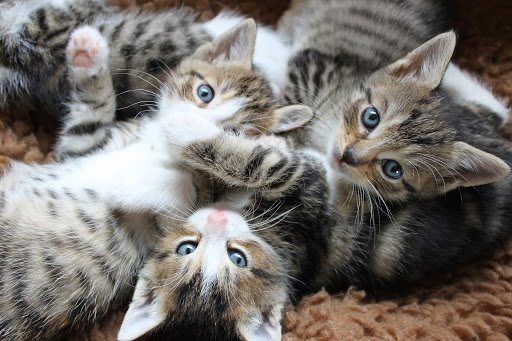


✅ Images loaded successfully!


In [2]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# WORKING EXAMPLE 1: Load and display images
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

# Load the images
cats = cv.imread("cats.jpg")
outing = cv.imread("outing_large.jpg")

# Display image information
print("Image Properties:")
print(f"\ncats.jpg:")
print(f"  Shape: {cats.shape}")
print(f"  Size: {cats.shape[1]}x{cats.shape[0]} pixels")

print(f"\nouting_large.jpg:")
print(f"  Shape: {outing.shape}")
print(f"  Size: {outing.shape[1]}x{outing.shape[0]} pixels")

# Display cats image
print("\nCats Image:")
cv2_imshow(cats)
print("\n✅ Images loaded successfully!")

---

## 📚 Section 2: Image Resizing - Working Example

Original size: 4959x3306 pixels
Resized (20%): 991x661 pixels

Resized Image (20% of original):


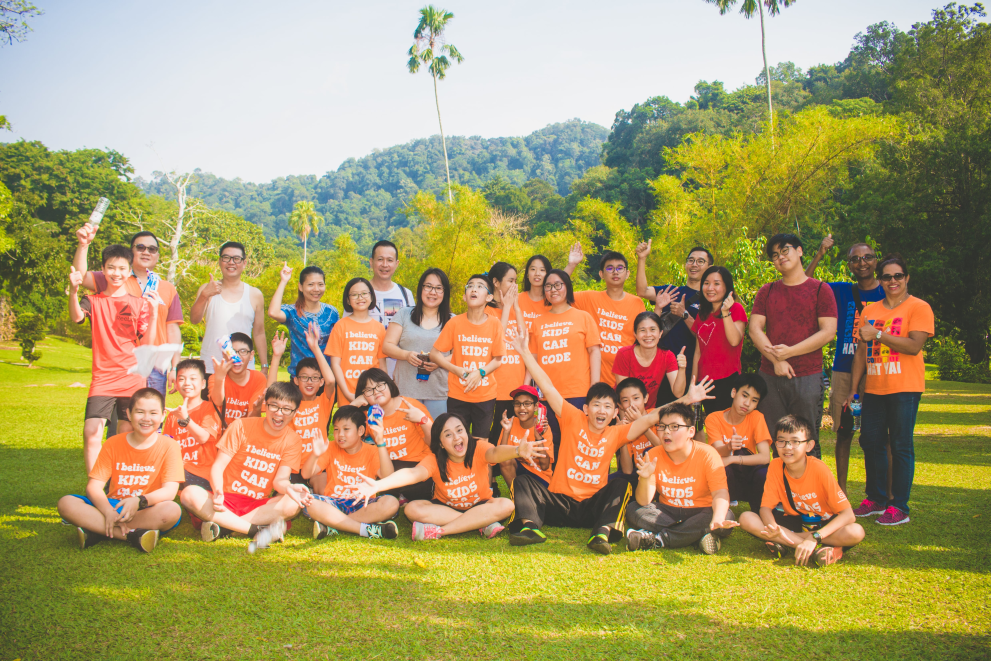


Resized (50%): 2479x1653 pixels

✅ Images resized successfully!


In [3]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# WORKING EXAMPLE 2: Resize images using scale factor
import cv2 as cv
from google.colab.patches import cv2_imshow

# Load large image
img = cv.imread("outing_large.jpg")
print(f"Original size: {img.shape[1]}x{img.shape[0]} pixels")

# Resize to 20% of original
scale = 0.2
width = int(img.shape[1] * scale)
height = int(img.shape[0] * scale)
dim = (width, height)

# Resize with INTER_AREA (best for shrinking)
resized = cv.resize(img, dim, interpolation=cv.INTER_AREA)

print(f"Resized (20%): {resized.shape[1]}x{resized.shape[0]} pixels")
print(f"\nResized Image (20% of original):")
cv2_imshow(resized)

# Also demonstrate upscaling
scale_up = 0.5
width_up = int(img.shape[1] * scale_up)
height_up = int(img.shape[0] * scale_up)
resized_50 = cv.resize(img, (width_up, height_up), interpolation=cv.INTER_AREA)

print(f"\nResized (50%): {resized_50.shape[1]}x{resized_50.shape[0]} pixels")
print("\n✅ Images resized successfully!")

---

## 📚 Section 3: Color Space Conversions - Working Example

Color Space Conversions:
Original (BGR): (341, 512, 3) - 3 channels
Grayscale: (341, 512) - 1 channel
HSV: (341, 512, 3) - 3 channels (Hue, Saturation, Value)
RGB: (341, 512, 3) - 3 channels (for display in other libraries)

Grayscale Image:


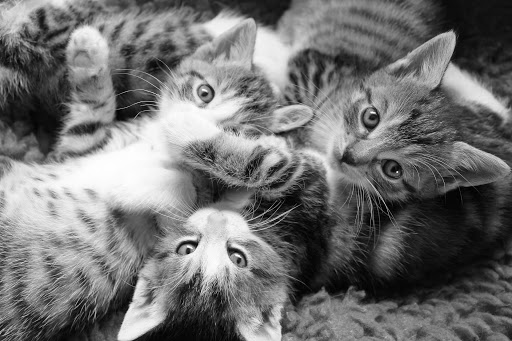


HSV Image (colors may look different due to display):


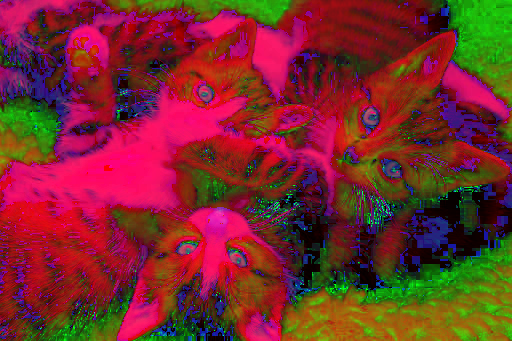


✅ Color conversions complete!


In [4]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# WORKING EXAMPLE 3: Convert between color spaces
import cv2 as cv
from google.colab.patches import cv2_imshow

# Load image
img = cv.imread("cats.jpg")

# Convert to different color spaces
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

print("Color Space Conversions:")
print(f"Original (BGR): {img.shape} - 3 channels")
print(f"Grayscale: {gray.shape} - 1 channel")
print(f"HSV: {hsv.shape} - 3 channels (Hue, Saturation, Value)")
print(f"RGB: {rgb.shape} - 3 channels (for display in other libraries)")

print("\nGrayscale Image:")
cv2_imshow(gray)

print("\nHSV Image (colors may look different due to display):")
cv2_imshow(hsv)

print("\n✅ Color conversions complete!")

---

## 📚 Section 4: Edge Detection and Blurring - Working Example

Image Processing Results:

1. Canny Edge Detection (detects boundaries):


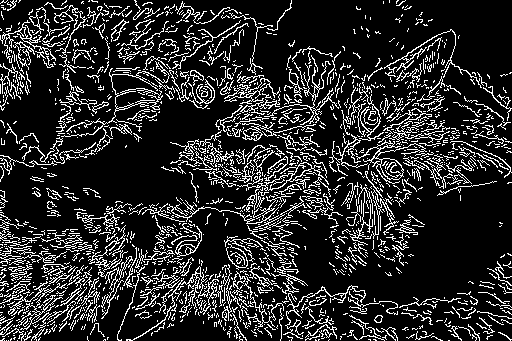


2. Gaussian Blur (smooths image, reduces noise):


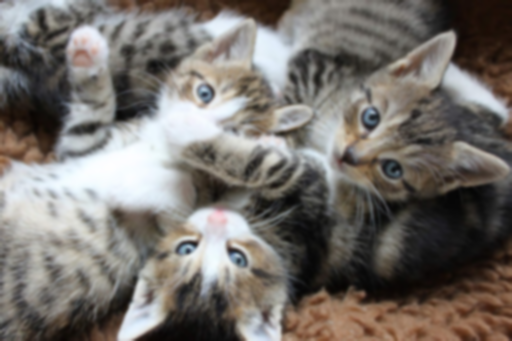


3. Strong Gaussian Blur (21x21 kernel):


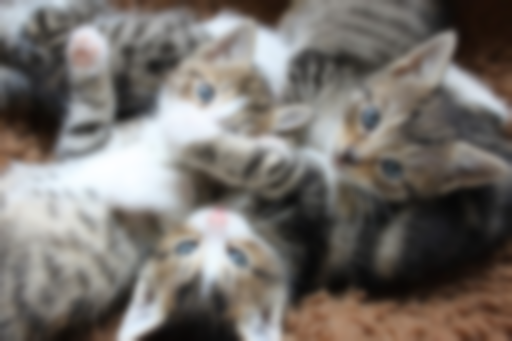


✅ Edge detection and blur applied!


In [5]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# WORKING EXAMPLE 4: Apply edge detection and blur
import cv2 as cv
from google.colab.patches import cv2_imshow

# Load image
img = cv.imread("cats.jpg")

# Canny edge detection
# Parameters: image, threshold1, threshold2
canny = cv.Canny(img, 125, 175)

# Gaussian blur
# Parameters: image, kernel_size, sigmaX (0 = auto-calculate)
blur = cv.GaussianBlur(img, (7, 7), 0)

print("Image Processing Results:")
print("\n1. Canny Edge Detection (detects boundaries):")
cv2_imshow(canny)

print("\n2. Gaussian Blur (smooths image, reduces noise):")
cv2_imshow(blur)

# Stronger blur
blur_strong = cv.GaussianBlur(img, (21, 21), 0)
print("\n3. Strong Gaussian Blur (21x21 kernel):")
cv2_imshow(blur_strong)

print("\n✅ Edge detection and blur applied!")

---

## 📝 TODO 1: Resize and Convert Image (Easy - 15 minutes)

**What You'll Build:** Resize the outing_large.jpg image and convert it to multiple formats.

**Success Criteria:**
- ✅ Resize outing_large.jpg to 20% of original size
- ✅ Convert the resized image to grayscale
- ✅ Convert the resized image to HSV color space
- ✅ Display all three versions (resized, gray, HSV)
- ✅ Print the dimensions of each version

**Hints:**
- 💡 Scale factor: `scale = 0.2`
- 💡 Calculate dimensions: `width = int(img.shape[1] * scale)`
- 💡 Resize: `cv.resize(img, (width, height), interpolation=cv.INTER_AREA)`
- 💡 To gray: `cv.cvtColor(resized, cv.COLOR_BGR2GRAY)`
- 💡 To HSV: `cv.cvtColor(resized, cv.COLOR_BGR2HSV)`

**Expected Output:**
Three images displayed: resized color image, grayscale version, and HSV version.

In [8]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# TODO 1: Resize and convert outing_large.jpg
import cv2 as cv
from google.colab.patches import cv2_imshow

# Load the large image
img = cv.imread("outing_large.jpg")

# Your code here:
# 1. Calculate 20% dimensions
scale = 0.2
width = int(img.shape[1] * scale)
height = int(img.shape[0] * scale)
dim = (width, height)



# 2. Resize the image
img_resized = cv.resize(img, dim, interpolation=cv.INTER_AREA)

# 3. Convert to grayscale
img_gray = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)

# 4. Convert to HSV
img_hsv = cv.cvtColor(img_resized, cv.COLOR_BGR2HSV)


# 5. Display all three versions and print dimensions
print("Resized image dimensions:", img_resized.shape[:2])
print("Grayscale image dimensions:", img_gray.shape[:2])
print("HSV image dimensions:", img_hsv.shape[:2])


Resized image dimensions: (661, 991)
Grayscale image dimensions: (661, 991)
HSV image dimensions: (661, 991)


---

## 📝 TODO 2: Apply Edge Detection and Blur (Medium - 20 minutes)

**What You'll Build:** Apply edge detection and blur to the cats.jpg image with different parameters.

**Success Criteria:**
- ✅ Apply Canny edge detection with thresholds (100, 150)
- ✅ Apply Canny edge detection with thresholds (50, 200) - compare results
- ✅ Apply Gaussian blur with kernel (5, 5)
- ✅ Apply Gaussian blur with kernel (15, 15) - compare results
- ✅ Display all four results with labels

**Hints:**
- 💡 Canny: `cv.Canny(img, threshold1, threshold2)`
- 💡 Lower thresholds = more edges detected
- 💡 Blur: `cv.GaussianBlur(img, (kernel_size, kernel_size), 0)`
- 💡 Larger kernel = more blur
- 💡 Kernel size must be odd (3, 5, 7, 9, etc.)

**Expected Output:**
Four processed images showing different edge detection sensitivities and blur strengths.

In [10]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# TODO 2: Apply edge detection and blur with different parameters
import cv2 as cv
from google.colab.patches import cv2_imshow

# Load the cats image
img = cv.imread("cats.jpg")

# Your code here:
# 1. Canny edge detection with thresholds (100, 150)
canny = cv.Canny(img, 100, 150)


# 2. Canny edge detection with thresholds (50, 200)
canny2 = cv.Canny(img, 50, 200)


# 3. Gaussian blur with kernel (5, 5)
blur = cv.GaussianBlur(img, (5, 5), 0)


# 4. Gaussian blur with kernel (15, 15)
blur2 = cv.GaussianBlur(img, (15, 15), 0)


# 5. Display all four results
print("Canny Edge Detection (100, 150):", canny.shape[:2])
print("Canny Edge Detection (50, 200):", canny2.shape[:2])
print("Gaussian Blur (5, 5):", blur.shape[:2])
print("Gaussian Blur (15, 15):", blur2.shape[:2])

Canny Edge Detection (100, 150): (341, 512)
Canny Edge Detection (50, 200): (341, 512)
Gaussian Blur (5, 5): (341, 512)
Gaussian Blur (15, 15): (341, 512)


---

## 🎉 Congratulations!

You've completed the Image Processing with OpenCV activity!

### What You Learned:

- ✅ **Image Resizing**: Used cv2.resize() with scale factors and interpolation
- ✅ **Color Conversions**: Converted BGR to grayscale, HSV, and RGB
- ✅ **Edge Detection**: Applied Canny algorithm with different thresholds
- ✅ **Image Blurring**: Used Gaussian blur with various kernel sizes

### Real-World Applications:

These techniques are essential for:
- **Preprocessing**: Preparing images for machine learning models
- **Object Detection**: Edge detection helps identify object boundaries
- **Noise Reduction**: Blurring removes image noise before analysis
- **Image Thumbnails**: Resizing for web and mobile applications
- **Color Analysis**: HSV color space for better color segmentation

### Next Steps:

1. ✅ Complete both TODO exercises
2. ✅ Run all cells to verify your code works
3. ✅ Save your notebook
4. ✅ Try the extension challenges below
5. ✅ Move on to Activity 15 - Drawing with OpenCV

---

### 🚀 Extension Challenges

**Beginner:**
- Upload your own image and apply all techniques
- Try different Canny threshold combinations

**Intermediate:**
- Apply blur before edge detection (reduces noise)
- Create a function that auto-scales images to max width

**Advanced:**
- Implement adaptive thresholding
- Create an image processing pipeline

---

**Total Time:** 45 minutes | **TODOs Completed:** ___ / 2

---

## 🎁 Bonus: Upload Your Own Image

Try the techniques you learned on your own image!

In [ ]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# ⚠️ Colab-only cell: `from google.colab import files` only exists inside Google Colab.
# In VS Code / local Jupyter you'll get `ModuleNotFoundError: No module named 'google'`.
# Locally, replace this cell with: `filename = "your_file.jpg"` after manually placing
# your image in the working directory. Or just open this notebook in Colab.

# BONUS: Upload and process your own image
from google.colab import files

print("Upload your own image to process:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\nProcessing: {filename}")

In [ ]:
# ⚠️ Colab-only cell — uses a JavaScript browser shim / Colab-patches helper.
# In VS Code / local Jupyter / any non-Colab environment, this cell will hang
# forever (you'll see "running 28.0s" with no output). If that happens,
# you're not in Colab — skip this cell or open the notebook in Colab.
# Process your uploaded image
import cv2 as cv
from google.colab.patches import cv2_imshow

# Load your image (replace 'filename' with actual name if needed)
# my_img = cv.imread(filename)

# Apply techniques:
# - Resize
# - Convert to grayscale
# - Apply edge detection
# - Apply blur

# Display results
print("Apply the techniques you learned to your own image!")